In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/preprocessed_df.csv")

In [3]:
df.head()

,Unnamed: 0,clean_comment,category
0,0,family mormon have never tried explain them th...,1
1,1,buddhism has very much lot compatible with chr...,1
2,2,seriously don say thing first all they won get...,-1
3,3,what you have learned yours and only yours wha...,0
4,4,for your own benefit you may want read living ...,1


In [98]:
df.columns[0]

'Unnamed: 0'

In [3]:
df.drop(columns=df.columns[0], inplace=True)

In [5]:
df.columns

Index(['clean_comment', 'category'], dtype='object')

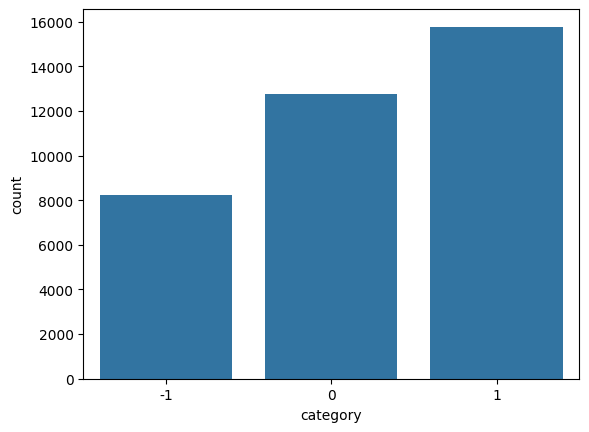

In [6]:
sns.countplot(data=df, x="category")
plt.show()

In [4]:
df['category'].value_counts(normalize=True).mul(100).round(2)

,proportion
category,
1,42.86
0,34.71
-1,22.42


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36793 entries, 0 to 36792
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  36793 non-null  object
 1   category       36793 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 575.0+ KB


In [9]:
len(df[df['category']==1.0])

15771

In [5]:
df_1= df[df['category']==1.0].reset_index()

In [6]:
len(df[df['category']==0.0])

12772

In [7]:
df_0= df[df['category']==0.0].reset_index()

In [13]:
len(df[df['category']==-1.0])

8250

In [8]:
df_neg_1= df[df['category']==-1.0].reset_index()

In [15]:
len(df_neg_1)

8250

In [16]:
df_neg_1.head()

,index,clean_comment,category
0,2,seriously don say thing first all they won get...,-1
1,5,you should all sit down together and watch the...,-1
2,8,there are two varieties christians dogmatic th...,-1
3,15,does evil include the lady pai chunked,-1
4,17,technically you could argue that sobek evil wo...,-1


In [112]:
df_neg_1.columns

Index(['index', 'clean_comment', 'category'], dtype='object')

In [9]:
df_neg_1.drop(columns=['index'], inplace=True)

In [114]:
df_neg_1

,clean_comment,category
0,seriously don say thing first all they won get...,-1
1,you should all sit down together and watch the...,-1
2,there are two varieties christians dogmatic th...,-1
3,does evil include the lady pai chunked,-1
4,technically you could argue that sobek evil wo...,-1
...,...,...
8245,how else supposed ask for your vote only viola...,-1
8246,modi like trump obsessed who criticizing him m...,-1
8247,fuck you nearly had want rush the atm,-1
8248,seriously the india hasn done any press confer...,-1


In [10]:
df_0.drop(columns=['index'], inplace=True)

In [11]:
df_0 = df_0.sample(n=8250, random_state=42)

In [12]:
df_0 = df_0.reset_index().drop(columns=['index'])

In [13]:
df_0

,clean_comment,category
0,what dick,0
1,kraków poland silent gathering next the consul...,0
2,chal jhootha,0
3,finally narendra nayak dancing somewhere with ...,0
4,jpaxte2h 8e07c016,0
...,...,...
8245,catalani ogni tanto vado europe solo per scriv...,0
8246,suppose this the state corruption scandals bjp...,0
8247,ugh gst and demo you dont know billion people ...,0
8248,what joke article,0


In [14]:
df_1.drop(columns=['index'], inplace=True)

In [15]:
df_1 = df_1.sample(n=8250, random_state=42)

In [16]:
df_1 = df_1.reset_index().drop(columns=['index'])

In [17]:
df_1

,clean_comment,category
0,near the window,1
1,that not how india works have parliamentary sy...,1
2,you are welcome,1
3,easy win for bjp congress nearly gone from ind...,1
4,awesome list could clarify that baldur said kr...,1
...,...,...
8245,that looks awesome,1
8246,modi has indeed got right using diaspora the h...,1
8247,moral victory for smriti irani rahul ran away ...,1
8248,wow they just discovered new tactic for campai...,1


In [18]:
df_balanced = pd.concat([df_1, df_0, df_neg_1], ignore_index=True)

In [19]:
df_balanced

,clean_comment,category
0,near the window,1
1,that not how india works have parliamentary sy...,1
2,you are welcome,1
3,easy win for bjp congress nearly gone from ind...,1
4,awesome list could clarify that baldur said kr...,1
...,...,...
24745,how else supposed ask for your vote only viola...,-1
24746,modi like trump obsessed who criticizing him m...,-1
24747,fuck you nearly had want rush the atm,-1
24748,seriously the india hasn done any press confer...,-1


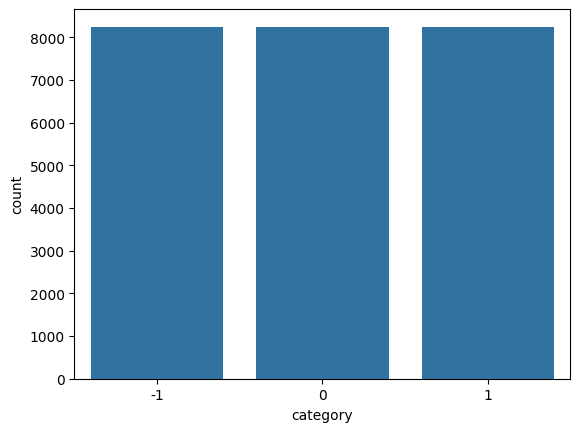

In [20]:
sns.countplot(data=df_balanced, x='category')
plt.show()

In [21]:
df_balanced['word_count'] = df_balanced['clean_comment'].apply(lambda x: len(x.split()))

In [22]:
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [23]:
df_balanced

,clean_comment,category,word_count
0,not indian what aadhaar,0,4
1,india has repeatedly approached usa and was re...,1,26
2,know that india wil give the most befitting re...,1,18
3,every citizen who linked their bank account aa...,0,13
4,chaliye vadraji wannakam,0,3
...,...,...,...
24745,realised this couple years back when got into ...,-1,130
24746,meet the new boss same the old boss,1,8
24747,people did not realise that always been critic...,1,22
24748,pata hai aap sabko,0,4


In [24]:
df_balanced['word_count'].describe()

,word_count
count,24750.000000
mean,28.900485
std,52.578927
min,1.000000
25%,7.000000
50%,14.000000
75%,30.000000
max,1301.000000


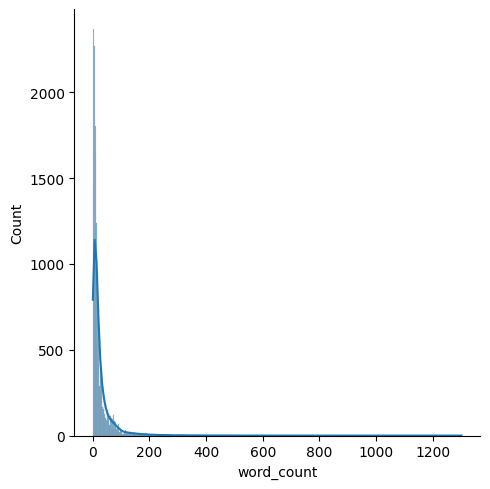

In [25]:
sns.displot(df_balanced['word_count'], kde=True)
plt.show()

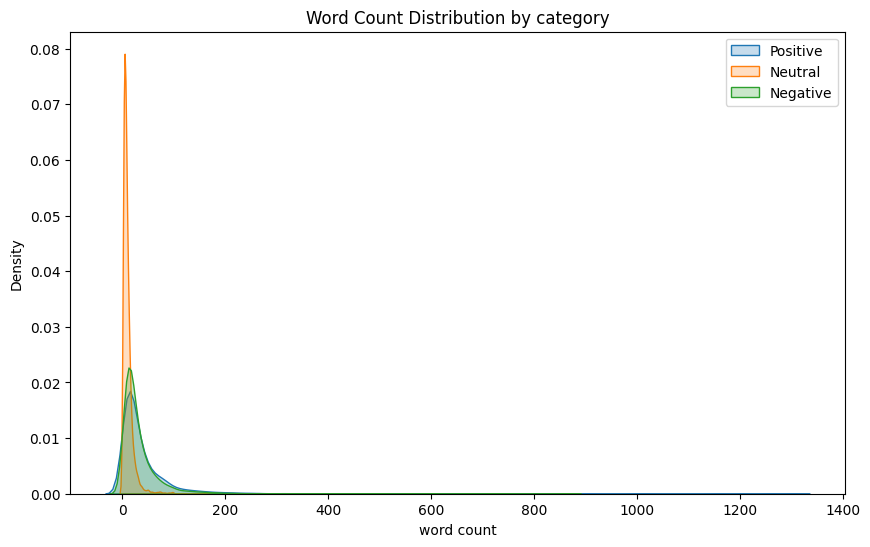

In [27]:
plt.figure(figsize=(10,6))

sns.kdeplot(df_balanced[df_balanced['category']==1.0]['word_count'], label="Positive", fill=True)

sns.kdeplot(df_balanced[df_balanced['category']==0.0]['word_count'], label="Neutral", fill=True)

sns.kdeplot(df_balanced[df_balanced['category']==-1.0]['word_count'], label="Negative", fill=True)

plt.title("Word Count Distribution by category")
plt.xlabel("word count")
plt.ylabel("Density")

plt.legend()

plt.show()

In [28]:
!pip install nltk

In [29]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [30]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

In [31]:
len(stop_words)

198

In [32]:
df_balanced['num_stop_words'] = df_balanced['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

In [33]:
df_balanced

,clean_comment,category,word_count,num_stop_words
0,not indian what aadhaar,0,4,2
1,india has repeatedly approached usa and was re...,1,26,10
2,know that india wil give the most befitting re...,1,18,7
3,every citizen who linked their bank account aa...,0,13,4
4,chaliye vadraji wannakam,0,3,0
...,...,...,...,...
24745,realised this couple years back when got into ...,-1,130,42
24746,meet the new boss same the old boss,1,8,3
24747,people did not realise that always been critic...,1,22,10
24748,pata hai aap sabko,0,4,0


In [34]:
from collections import Counter

all_text = ' '.join(df_balanced['clean_comment'])

char_frequency = Counter(all_text)

char_frequency_df = pd.DataFrame(char_frequency.items(), columns=["Char", "Freq", ]).sort_values(by="Freq", ascending=True)

In [35]:
char_frequency_df['Char'].values

array(['问', '残', '猴', ..., 't', 'e', ' '], dtype=object)

In [36]:
char_frequency_df

,Char,Freq
1025,问,1
1024,残,1
1023,猴,1
1022,顶,1
1021,错,1
...,...,...
4,i,262882
6,a,315359
2,t,321098
11,e,434395


In [37]:
df_balanced['num_chars'] = df_balanced['clean_comment'].apply(len)

In [38]:
df_balanced

,clean_comment,category,word_count,num_stop_words,num_chars
0,not indian what aadhaar,0,4,2,23
1,india has repeatedly approached usa and was re...,1,26,10,169
2,know that india wil give the most befitting re...,1,18,7,99
3,every citizen who linked their bank account aa...,0,13,4,80
4,chaliye vadraji wannakam,0,3,0,24
...,...,...,...,...,...
24745,realised this couple years back when got into ...,-1,130,42,867
24746,meet the new boss same the old boss,1,8,3,35
24747,people did not realise that always been critic...,1,22,10,123
24748,pata hai aap sabko,0,4,0,18


In [39]:
df_balanced['num_punctuation_chars'] = df_balanced['clean_comment'].apply(
    lambda x: sum([1 for char in x if char in '.,!%^&*()-_=\'[]{}'])
)

In [40]:
df_balanced

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,not indian what aadhaar,0,4,2,23,0
1,india has repeatedly approached usa and was re...,1,26,10,169,0
2,know that india wil give the most befitting re...,1,18,7,99,0
3,every citizen who linked their bank account aa...,0,13,4,80,0
4,chaliye vadraji wannakam,0,3,0,24,0
...,...,...,...,...,...,...
24745,realised this couple years back when got into ...,-1,130,42,867,0
24746,meet the new boss same the old boss,1,8,3,35,0
24747,people did not realise that always been critic...,1,22,10,123,0
24748,pata hai aap sabko,0,4,0,18,0


In [41]:
df_balanced['num_punctuation_chars'].describe()

,num_punctuation_chars
count,24750.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [44]:
# removing non-english and non-digits chars from comment column
import re

df_balanced['clean_comment'] = df_balanced['clean_comment'].apply(lambda x: re.sub(r'[^A-Za-z0-9\s!?.,]', '', str(x)))

In [45]:
df_balanced

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,not indian what aadhaar,0,4,2,23,0
1,india has repeatedly approached usa and was re...,1,26,10,169,0
2,know that india wil give the most befitting re...,1,18,7,99,0
3,every citizen who linked their bank account aa...,0,13,4,80,0
4,chaliye vadraji wannakam,0,3,0,24,0
...,...,...,...,...,...,...
24745,realised this couple years back when got into ...,-1,130,42,867,0
24746,meet the new boss same the old boss,1,8,3,35,0
24747,people did not realise that always been critic...,1,22,10,123,0
24748,pata hai aap sabko,0,4,0,18,0


In [46]:
stop_words = set(stopwords.words("english")) - {"not", "but", "however", "no", "yet"}

In [47]:
len(stop_words)

195

In [48]:
df_balanced['clean_comment'] = df_balanced['clean_comment'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words])
)

In [49]:
df_balanced

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,not indian aadhaar,0,4,2,23,0
1,india repeatedly approached usa repeatedly ign...,1,26,10,169,0
2,know india wil give befitting reply attack inn...,1,18,7,99,0
3,every citizen linked bank account aadhaar get ...,0,13,4,80,0
4,chaliye vadraji wannakam,0,3,0,24,0
...,...,...,...,...,...,...
24745,realised couple years back got conversations f...,-1,130,42,867,0
24746,meet new boss old boss,1,8,3,35,0
24747,people not realise always critical edgy matter...,1,22,10,123,0
24748,pata hai aap sabko,0,4,0,18,0


In [50]:
from nltk.stem import WordNetLemmatizer

nltk.download("wordnet")

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [51]:
lemmatizer = WordNetLemmatizer()

df_balanced['clean_comment'] = df_balanced['clean_comment'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()])
)

In [52]:
df_balanced

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,not indian aadhaar,0,4,2,23,0
1,india repeatedly approached usa repeatedly ign...,1,26,10,169,0
2,know india wil give befitting reply attack inn...,1,18,7,99,0
3,every citizen linked bank account aadhaar get ...,0,13,4,80,0
4,chaliye vadraji wannakam,0,3,0,24,0
...,...,...,...,...,...,...
24745,realised couple year back got conversation fel...,-1,130,42,867,0
24746,meet new bos old bos,1,8,3,35,0
24747,people not realise always critical edgy matter...,1,22,10,123,0
24748,pata hai aap sabko,0,4,0,18,0


In [53]:
from wordcloud import WordCloud

def plot_wordcloud(text):
  wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
  plt.figure(figsize=(10,5))
  plt.imshow(wordcloud, interpolation="bilinear")
  plt.axis("off")
  plt.show()

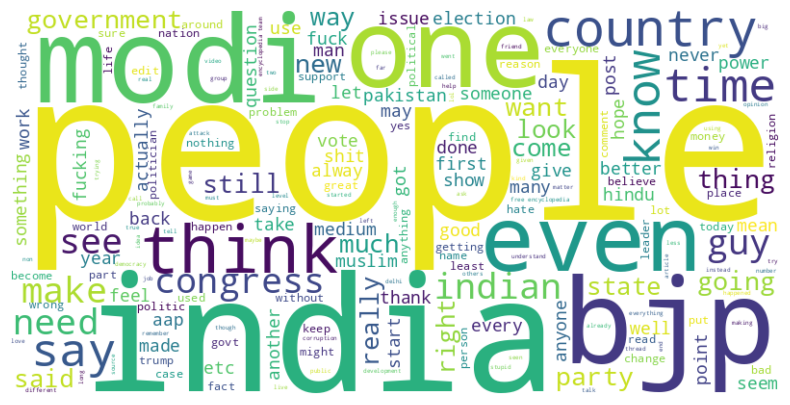

In [54]:
plot_wordcloud(df_balanced['clean_comment'])